<a href="https://colab.research.google.com/github/Namesakenberg/BrickByBrickML/blob/main/inference_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/gurgaon_properties_post_feature_selection_v2.csv')

In [ ]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,0.0,0.0,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,1.0,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,1.0,0.0,High,Mid Floor


In [ ]:
df = df.drop(columns =['store room' ,'floor_category','balcony'])         # least important columns

In [ ]:
df.head()

,property_type,sector,price,bedRoom,bathroom,agePossession,built_up_area,servant room,furnishing_type,luxury_category
0,flat,sector 36,0.82,3.0,2.0,New Property,850.0,0.0,0.0,Low
1,flat,sector 89,0.95,2.0,2.0,New Property,1226.0,1.0,0.0,Low
2,flat,sohna road,0.32,2.0,2.0,New Property,1000.0,0.0,0.0,Low
3,flat,sector 92,1.60,3.0,4.0,Relatively New,1615.0,1.0,1.0,High
4,flat,sector 102,0.48,2.0,2.0,Relatively New,582.0,0.0,0.0,High


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3554 non-null   object 
 1   sector           3554 non-null   object 
 2   price            3554 non-null   float64
 3   bedRoom          3554 non-null   float64
 4   bathroom         3554 non-null   float64
 5   agePossession    3554 non-null   object 
 6   built_up_area    3554 non-null   float64
 7   servant room     3554 non-null   float64
 8   furnishing_type  3554 non-null   float64
 9   luxury_category  3554 non-null   object 
dtypes: float64(6), object(4)
memory usage: 277.8+ KB


# Preprocessing

In [ ]:
# encoding the categorical columns

# numerical : price , bedroom , bathroom , built_up_area ,servant room
# cateorical : property type , sector , agePossession , luxury_category,

# sector -> one hot encode
# ordianl -> property type , agepossession , luxury category , furnishing

In [ ]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1732
Moderately Old,619
New Property,599
Old Property,327
Under Construction,277


In [ ]:
df['agePossession'] = df['agePossession'].replace(
    {
        'Relatively New' : 'new',
        'New Property' : 'new',
        'Moderately Old' : 'old',
        'Old Property' : 'old',
    }
)

In [ ]:
df['agePossession'].value_counts()

,count
agePossession,
new,2331
old,946
Under Construction,277


In [ ]:
df['property_type']  = df['property_type'].replace({'flat' : 0 , 'house' : 1})

/tmp/ipython-input-137-4118931184.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['property_type']  = df['property_type'].replace({'flat' : 0 , 'house' : 1})


In [ ]:
df.head()

,property_type,sector,price,bedRoom,bathroom,agePossession,built_up_area,servant room,furnishing_type,luxury_category
0,0,sector 36,0.82,3.0,2.0,new,850.0,0.0,0.0,Low
1,0,sector 89,0.95,2.0,2.0,new,1226.0,1.0,0.0,Low
2,0,sohna road,0.32,2.0,2.0,new,1000.0,0.0,0.0,Low
3,0,sector 92,1.60,3.0,4.0,new,1615.0,1.0,1.0,High
4,0,sector 102,0.48,2.0,2.0,new,582.0,0.0,0.0,High


In [ ]:
df['luxury_category'].value_counts()

,count
luxury_category,
Low,1594
Medium,1465
High,495


In [ ]:
df['luxury_category']= df['luxury_category'].replace({'Low':0  ,'Medium':1 , 'High':2})

/tmp/ipython-input-140-1768734087.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['luxury_category']= df['luxury_category'].replace({'Low':0  ,'Medium':1 , 'High':2})


In [ ]:
df.head()

,property_type,sector,price,bedRoom,bathroom,agePossession,built_up_area,servant room,furnishing_type,luxury_category
0,0,sector 36,0.82,3.0,2.0,new,850.0,0.0,0.0,0
1,0,sector 89,0.95,2.0,2.0,new,1226.0,1.0,0.0,0
2,0,sohna road,0.32,2.0,2.0,new,1000.0,0.0,0.0,0
3,0,sector 92,1.60,3.0,4.0,new,1615.0,1.0,1.0,2
4,0,sector 102,0.48,2.0,2.0,new,582.0,0.0,0.0,2


In [ ]:
# one hot encoding :
# using get dummies() instead of one hot encoder as pipeline will not be used.
# pipeline is not used as pipeline removes the names of the columns , since we are doing inference , names of the columns are necessary

In [ ]:
new_df = pd.get_dummies(df  , columns= ['sector','agePossession'],drop_first=True,dtype='int')

In [ ]:
new_df.head()

,property_type,price,bedRoom,bathroom,built_up_area,servant room,furnishing_type,luxury_category,sector_gwal pahari,sector_manesar,...,sector_sector 9,sector_sector 90,sector_sector 91,sector_sector 92,sector_sector 93,sector_sector 95,sector_sector 99,sector_sohna road,agePossession_new,agePossession_old
0,0,0.82,3.0,2.0,850.0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0.95,2.0,2.0,1226.0,1.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0.32,2.0,2.0,1000.0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
3,0,1.60,3.0,4.0,1615.0,1.0,1.0,2,0,0,...,0,0,0,1,0,0,0,0,1,0
4,0,0.48,2.0,2.0,582.0,0.0,0.0,2,0,0,...,0,0,0,0,0,0,0,0,1,0


# Linear Regression for inference

In [ ]:
X = new_df.drop(columns=['price'])
y = new_df['price']

In [ ]:
print(X.shape , y.shape)

(3554, 112) (3554,)


<Axes: xlabel='price', ylabel='Density'>

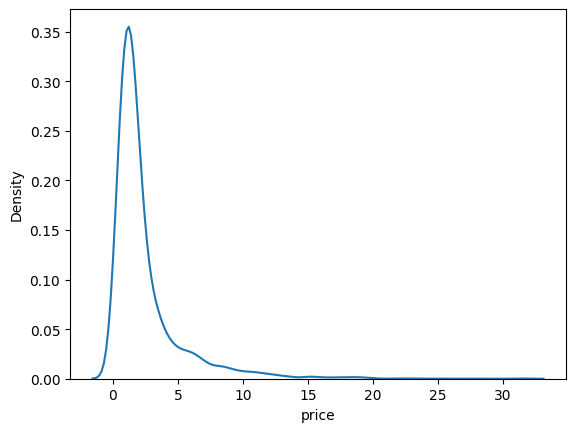

In [ ]:
sns.kdeplot(new_df['price'])

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_scaled = sc.fit_transform(X)

In [ ]:
X_scaled_df = pd.DataFrame(x_scaled , columns=X.columns)

In [ ]:
X_scaled_df.head()

,property_type,bedRoom,bathroom,built_up_area,servant room,furnishing_type,luxury_category,sector_gwal pahari,sector_manesar,sector_sector 1,...,sector_sector 9,sector_sector 90,sector_sector 91,sector_sector 92,sector_sector 93,sector_sector 95,sector_sector 99,sector_sohna road,agePossession_new,agePossession_old
0,-0.51718,-0.074329,-0.874300,-0.831662,-0.747968,-0.668281,-0.984642,-0.071348,-0.093805,-0.041123,...,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245,0.724339,-0.602271
1,-0.51718,-0.877269,-0.874300,-0.522517,1.336956,-0.668281,-0.984642,-0.071348,-0.093805,-0.041123,...,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245,0.724339,-0.602271
2,-0.51718,-0.877269,-0.874300,-0.708333,-0.747968,-0.668281,-0.984642,-0.071348,-0.093805,-0.041123,...,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,4.561105,0.724339,-0.602271
3,-0.51718,-0.074329,0.505173,-0.202684,1.336956,1.037949,1.866207,-0.071348,-0.093805,-0.041123,...,-0.078923,-0.160267,-0.069328,5.877074,-0.050386,-0.125375,-0.109357,-0.219245,0.724339,-0.602271
4,-0.51718,-0.877269,-0.874300,-1.052010,-0.747968,-0.668281,1.866207,-0.071348,-0.093805,-0.041123,...,-0.078923,-0.160267,-0.069328,-0.170153,-0.050386,-0.125375,-0.109357,-0.219245,0.724339,-0.602271


In [ ]:
from sklearn.model_selection import KFold , cross_val_score
from sklearn.linear_model import LinearRegression
kfold = KFold(n_splits= 10 , shuffle=True , random_state= 42)
scores = cross_val_score(LinearRegression(), x_scaled ,y ,cv=kfold , scoring='r2' )

In [ ]:
print(np.mean(scores) , np.std(scores))

0.7561969040363306 0.037144667408828734


In [ ]:
lr = LinearRegression()
lr.fit(x_scaled , y)

coef_df = pd.DataFrame(lr.coef_.reshape(1,112) , columns = X.columns).stack().reset_index().drop(columns =['level_0']).rename(columns={'level_1':'feature' , 0:'weight'})

In [ ]:
coef_df

,feature,weight
0,property_type,0.709011
1,bedRoom,0.088170
2,bathroom,0.213876
3,built_up_area,1.276216
4,servant room,0.125664
...,...,...
107,sector_sector 95,0.038982
108,sector_sector 99,0.025027
109,sector_sohna road,0.084572
110,agePossession_new,-0.074709


# Regression analysis

In [ ]:
import statsmodels.api as sm

# add constant
X_with_const = sm.add_constant(x_scaled)

# fit
model = sm.OLS(y , X_with_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     112.9
Date:                Thu, 10 Jul 2025   Prob (F-statistic):               0.00
Time:                        02:35:06   Log-Likelihood:                -5941.0
No. Observations:                3554   AIC:                         1.211e+04
Df Residuals:                    3441   BIC:                         1.281e+04
Df Model:                         112                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4415      0.022    111.240      0.0

In [ ]:
'''
each coefficient of the feature tells "by what value would y increase if the value of the feature is changed" i.e  y per unit of the feature .

but this is only applicable in case of unscaled coefficients ,
since the X is scaled and y is log transformed , the meaning of the coefficients is not as same as before.

thus to understand the actual relation between the feature and the output (y) , conversion of scaled coefficents to unscaled coeffs. is needed.

thus conversion of scaled coefficients to unscaled coeffiecients is done using the formula :

multiply the coefficient by the standard deviation of the covariate and add the mean.

formula :

standardized coeff =  unstandardized coeff * [(std. dev of feature befre scaling) / std. dev of log(y)]


thus :

 unstandardized coeff  = standardized coeff * [std. dev of log(y) / (std. dev of feature before scaling)]

 final_unstandardized_coeff = np.exp1(unstandardized coeff)   ***

'''

'\neach coefficient of the feature tells "by what value would y increase if the value of the feature is changed" i.e  y per unit of the feature .\n\nbut this is only applicable in case of unscaled coefficients ,\nsince the X is scaled and y is log transformed , the meaning of the coefficients is not as same as before.\n\nthus to understand the actual relation between the feature and the output (y) , conversion of scaled coefficents to unscaled coeffs. is needed.\n\nthus conversion of scaled coefficients to unscaled coeffiecients is done using the formula :\n\nmultiply the coefficient by the standard deviation of the covariate and add the mean.\n\nformula :\n\nstandardized coeff =  unstandardized coeff * [(std. dev of feature befre scaling) / std. dev of log(y)]\n\n\nthus :\n\n unstandardized coeff  = standardized coeff * [std. dev of log(y) / (std. dev of feature before scaling)]\n\n final_unstandardized_coeff = np.exp1(unstandardized coeff)   ***\n\n'

In [ ]:
print(coef_df.query("feature == 'bedRoom'"))
std_y = (y).std()
std_bedroom = df['bedRoom'].std()

print("Std of (price):", std_y)
print("Std of bedRoom:", std_bedroom)
beta_scaled = 0.08                  # From your model
beta_unscaled = beta_scaled * (std_y / std_bedroom)
print(beta_unscaled)

   feature   weight
1  bedRoom  0.08817
Std of (price): 2.783788325195031
Std of bedRoom: 1.2455995038118517
0.17879187117052822


In [ ]:
print(coef_df.query("feature == 'bathroom'"))
std_y = (y).std()
std_bathroom = df['bathroom'].std()

print("Std of price:", std_y)
print("Std of bathroom:", std_bathroom)
beta_scaled = 0.21                 # From your model
beta_unscaled = beta_scaled * (std_y / std_bathroom)
print(beta_unscaled)

    feature    weight
2  bathroom  0.213876
Std of price: 2.783788325195031
Std of bathroom: 1.4500333261235325
0.40316007760579775
